<a href="https://colab.research.google.com/github/2303A52464/GAI-2464/blob/main/Gen_AI_Project_Code(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Handwritten Digits-Classification using Deeplearning**
**Source Code**

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab. Skipping Google Drive mount.")


Not running in Google Colab. Skipping Google Drive mount.


#**Importing The libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report
seed=4
tf.random.set_seed(4)

**Load The MNIST data set from keras and Kaagle**

In [3]:
data = tf.keras.datasets.mnist
(X_train, Y_train), (X_test, Y_test) = data.load_data()

In [4]:
X_train = np.concatenate((X_train, X_test))
y_train = np.concatenate((Y_train, Y_test))
y_train = y_train.astype(int)
X_train.shape, y_train.shape

((70000, 28, 28), (70000,))

In [5]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
y_train

array([5, 0, 4, ..., 4, 5, 6])

In [7]:
len(pd.unique(y_train))

10

In [8]:
# Load the dataset into pandas DataFrames
import os
import pandas as pd
import numpy as np

# If train.csv and test.csv don't exist locally or in /content/, we generate them from Keras MNIST
if not os.path.exists('train.csv') and not os.path.exists('/content/train.csv'):
    print("Generating train.csv and test.csv from Keras MNIST dataset for seamless execution...")
    import tensorflow as tf
    (X_train_mnist, Y_train_mnist), (X_test_mnist, Y_test_mnist) = tf.keras.datasets.mnist.load_data()
    
    # train.csv: 42000 rows (labels + pixels)
    train_pixels = X_train_mnist[:42000].reshape(42000, 784)
    train_labels = Y_train_mnist[:42000]
    train_df = pd.DataFrame(train_pixels, columns=[f'pixel{i}' for i in range(784)])
    train_df.insert(0, 'label', train_labels)
    train_df.to_csv('train.csv', index=False)
    print("Generated train.csv")
    
    # test.csv: 28000 rows (pixels only)
    test_pixels_part1 = X_train_mnist[42000:].reshape(18000, 784)
    test_pixels_part2 = X_test_mnist[:10000].reshape(10000, 784)
    test_pixels = np.vstack((test_pixels_part1, test_pixels_part2))
    test_df = pd.DataFrame(test_pixels, columns=[f'pixel{i}' for i in range(784)])
    test_df.to_csv('test.csv', index=False)
    print("Generated test.csv")

if os.path.exists('train.csv'):
    valid_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')
else:
    valid_data = pd.read_csv('/content/train.csv')
    test_data = pd.read_csv('/content/test.csv')


**Data Preprocessing**

In [9]:
y_validation = valid_data['label'].values
x_validation = valid_data.drop('label', axis = 1).values
x_validation

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [10]:
y_validation

array([5, 0, 4, ..., 2, 7, 0], dtype=int64)

**Reshaping The data**

In [11]:
x_train = X_train.reshape(X_train.shape[0], 28,28)
x_validation = x_validation.reshape(x_validation.shape[0],28,28)
x_test = test_data.values.reshape(test_data.shape[0], 28,28)

x_train.shape, y_train.shape, x_validation.shape, y_validation.shape,  x_test.shape

((70000, 28, 28), (70000,), (42000, 28, 28), (42000,), (28000, 28, 28))

**Plot the first sample digit images with their actual label**

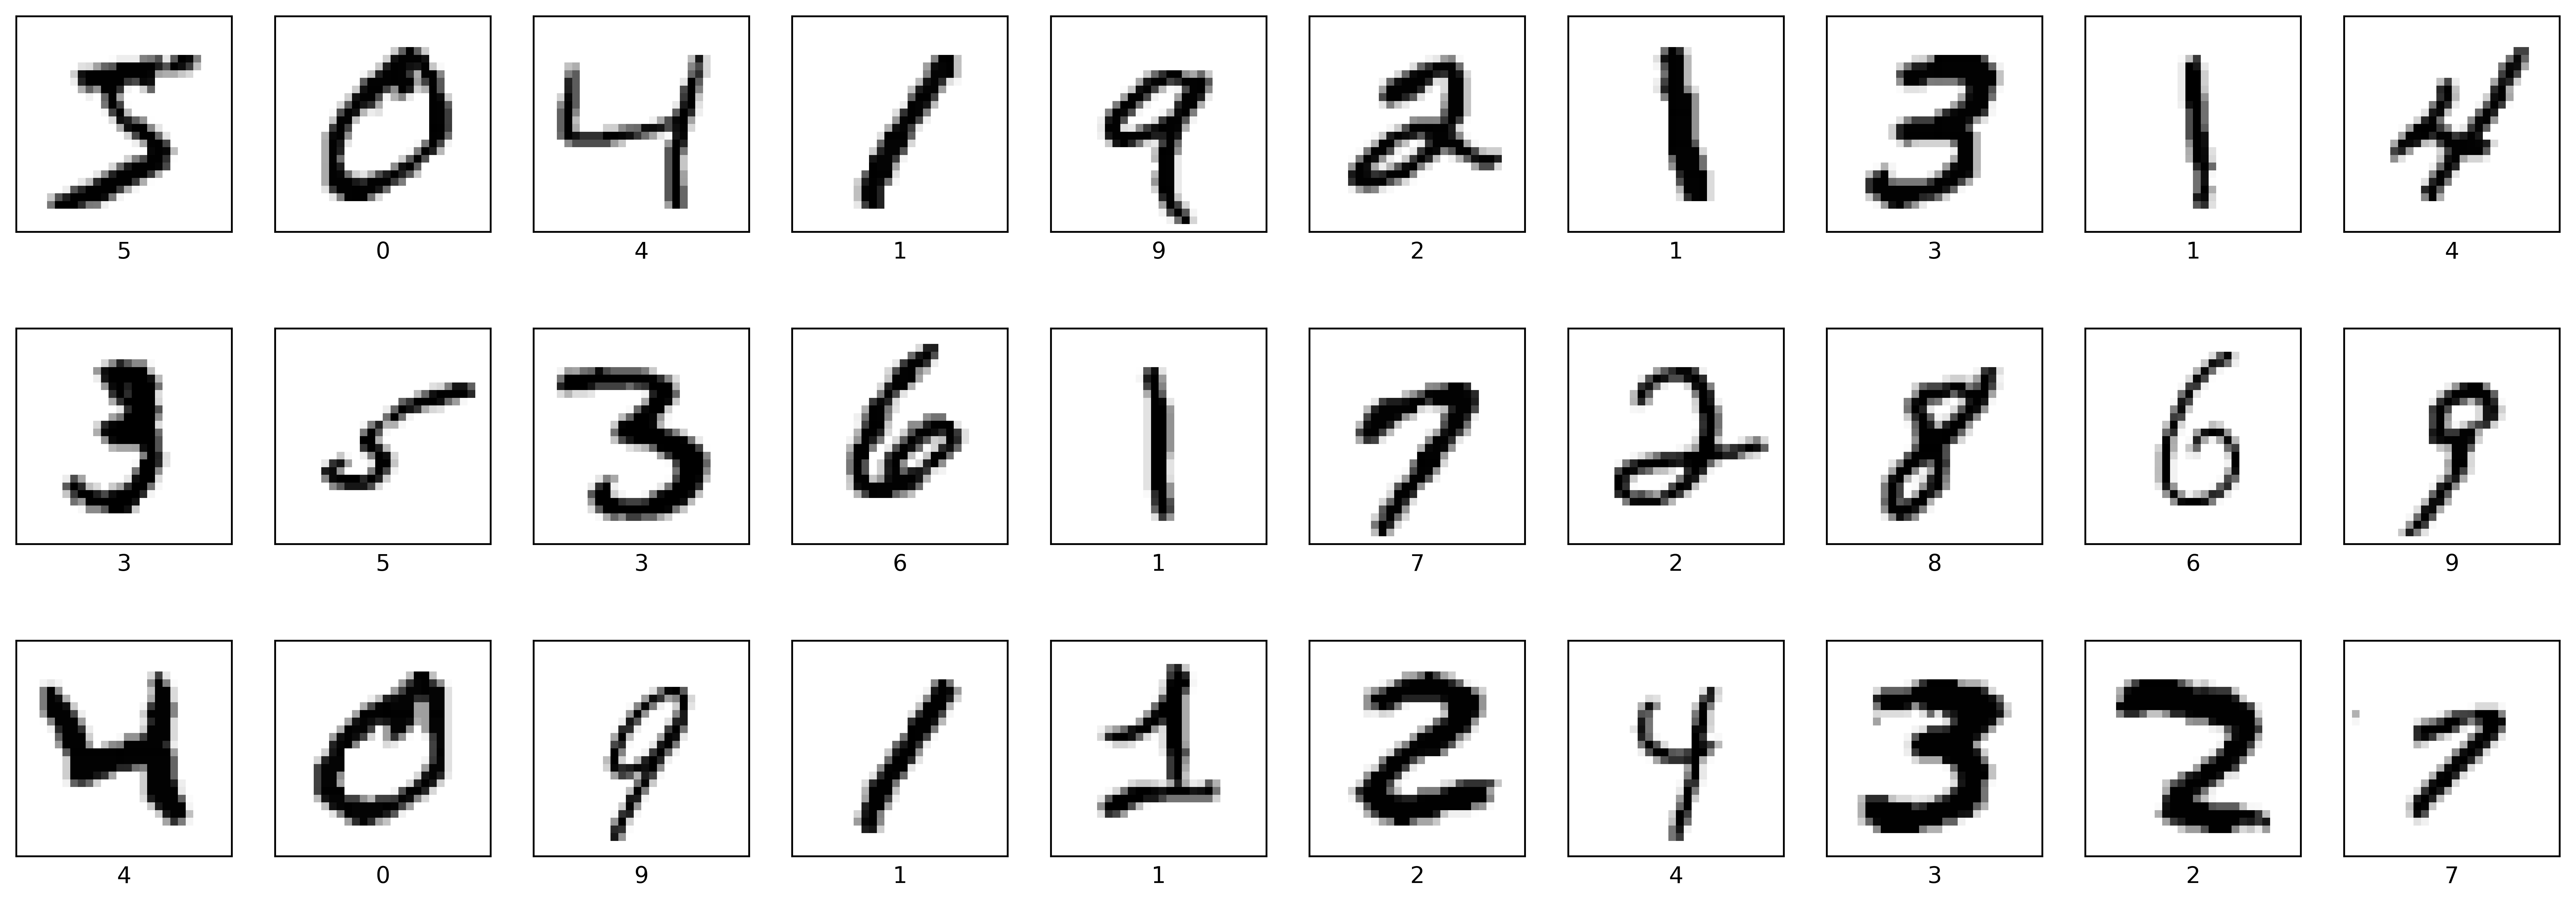

In [12]:
plt.figure(figsize=(20,7), dpi = 523)
for i in range(30):
    plt.subplot(3,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

**Adding Dimension**

In [13]:
x_train = x_train.reshape(-1,28,28,1)
x_valid = x_validation.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

print('Train Data shape      :',x_train.shape)
print('Validation Data shape :',x_valid.shape)
print('Test Data shape       :',x_test.shape)

Train Data shape      : (70000, 28, 28, 1)
Validation Data shape : (42000, 28, 28, 1)
Test Data shape       : (28000, 28, 28, 1)


**Normalization**

In [14]:
x_train, x_valid, x_test = x_train / 255, x_valid / 255, x_test / 255


**Encoding the labels**

In [15]:
y_train_ = tf.keras.utils.to_categorical(y_train)
y_valid_ = tf.keras.utils.to_categorical(y_validation)

**Model Implementation**

In [16]:
batch = 1000
epochs = 2

steps_per_epoch = x_train.shape[0]//batch
steps_per_epoch

70

In [17]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=10,zoom_range=0.15)

image_generator = datagen.flow(x_train, y_train_, batch_size=batch, seed=seed,)

In [18]:
print('The Unique digits are :', sorted(pd.unique(y_train)))
n = len(pd.unique(y_train))
print('There are total',n, 'unique digits')

The Unique digits are : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
There are total 10 unique digits


In [19]:
model = models.Sequential([
    layers.Conv2D(filters=64, kernel_size=(2, 2), activation='relu', input_shape = (28,28,1)),         # Convolution Layer with relu
    layers.Conv2D(64, (4, 4), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(filters=64, kernel_size=(2, 2), activation='relu'),         # Convolution Layer with relu
    layers.Conv2D(64, (4, 4), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),                                         # MaxPooling layer with relu

    layers.Conv2D(128, (3, 3), activation = 'relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(150, activation = tf.nn.relu),     # Hidden layer 1
    layers.Dense(150, activation = tf.nn.relu),      # Hidden layer2
    layers.Dense(n, activation = tf.nn.softmax)     # Output layer softmax
])

C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 27, 27, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │        76,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,958 (1.24 MB)

 Trainable params: 323,446 (1.23 MB)

 Non-trainable params: 512 (2.00 KB)

**Visualizing the model**

In [21]:
try:
    tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True)
except Exception as e:
    print(f"Skipping model plotting: pydot/graphviz not installed. Error: {e}")


You must install pydot (`pip install pydot`) for `plot_model` to work.


In [22]:
### .et the learning rate =
lr_rate = 0.0001
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_accuracy',
                                                  patience = 3,
                                                  min_delta = 1e-4,
                                                  restore_best_weights = True)
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath = 'saved_model/best_model_todate.weights.h5',
                                                 save_best_only = True,
                                                 save_weights_only = True,
                                                 monitor='val_accuracy',
                                                 mode='max')
tn = tf.keras.callbacks.TerminateOnNaN()
scheduler = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate = lr_rate,
                                                           decay_steps = steps_per_epoch//4,
                                                           decay_rate= 0.80,
                                                           staircase=True)
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: float(scheduler(epoch)))
lr_plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss',
                                                  factor = 0.1,
                                                  patience = 4,
                                                  verbose = 3)

**optimizer and loss function for training**

In [23]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_rate)

**model compilation**

In [24]:
model.compile(optimizer=optimizer,loss=loss_object, metrics=['accuracy'])



**Training the model**




In [25]:
# Train the model
history = model.fit(
    image_generator,
    epochs=epochs,
    validation_data=(x_valid, y_valid_),
    callbacks=[early_stopping, checkpoint_callback, tn, lr_scheduler, lr_plateau]
)

history_dict = history.history
history_dict.keys()

Epoch 1/2


 1/70 ━━━━━━━━━━━━━━━━━━━━ 6:23 6s/step - accuracy: 0.0890 - loss: 2.5694

 2/70 ━━━━━━━━━━━━━━━━━━━━ 2:34 2s/step - accuracy: 0.1010 - loss: 2.5319

 3/70 ━━━━━━━━━━━━━━━━━━━━ 2:52 3s/step - accuracy: 0.1126 - loss: 2.4912

 4/70 ━━━━━━━━━━━━━━━━━━━━ 2:39 2s/step - accuracy: 0.1239 - loss: 2.4524

 5/70 ━━━━━━━━━━━━━━━━━━━━ 2:33 2s/step - accuracy: 0.1365 - loss: 2.4155

 6/70 ━━━━━━━━━━━━━━━━━━━━ 2:26 2s/step - accuracy: 0.1500 - loss: 2.3809

 7/70 ━━━━━━━━━━━━━━━━━━━━ 2:20 2s/step - accuracy: 0.1643 - loss: 2.3475

 8/70 ━━━━━━━━━━━━━━━━━━━━ 2:17 2s/step - accuracy: 0.1788 - loss: 2.3153

 9/70 ━━━━━━━━━━━━━━━━━━━━ 2:12 2s/step - accuracy: 0.1927 - loss: 2.2850

10/70 ━━━━━━━━━━━━━━━━━━━━ 2:09 2s/step - accuracy: 0.2065 - loss: 2.2557

11/70 ━━━━━━━━━━━━━━━━━━━━ 2:05 2s/step - accuracy: 0.2200 - loss: 2.2273

12/70 ━━━━━━━━━━━━━━━━━━━━ 2:02 2s/step - accuracy: 0.2331 - loss: 2.1999

13/70 ━━━━━━━━━━━━━━━━━━━━ 1:59 2s/step - accuracy: 0.2459 - loss: 2.1734

14/70 ━━━━━━━━━━━━━━━━━━━━ 1:56 2s/step - accuracy: 0.2584 - loss: 2.1476

15/70 ━━━━━━━━━━━━━━━━━━━━ 1:54 2s/step - accuracy: 0.2704 - loss: 2.1229

16/70 ━━━━━━━━━━━━━━━━━━━━ 1:51 2s/step - accuracy: 0.2820 - loss: 2.0990

17/70 ━━━━━━━━━━━━━━━━━━━━ 1:48 2s/step - accuracy: 0.2931 - loss: 2.0759

18/70 ━━━━━━━━━━━━━━━━━━━━ 1:46 2s/step - accuracy: 0.3039 - loss: 2.0534

19/70 ━━━━━━━━━━━━━━━━━━━━ 1:43 2s/step - accuracy: 0.3144 - loss: 2.0316

20/70 ━━━━━━━━━━━━━━━━━━━━ 1:41 2s/step - accuracy: 0.3245 - loss: 2.0103

21/70 ━━━━━━━━━━━━━━━━━━━━ 1:40 2s/step - accuracy: 0.3342 - loss: 1.9896

22/70 ━━━━━━━━━━━━━━━━━━━━ 1:38 2s/step - accuracy: 0.3435 - loss: 1.9696

23/70 ━━━━━━━━━━━━━━━━━━━━ 1:36 2s/step - accuracy: 0.3526 - loss: 1.9500

24/70 ━━━━━━━━━━━━━━━━━━━━ 1:34 2s/step - accuracy: 0.3613 - loss: 1.9309

25/70 ━━━━━━━━━━━━━━━━━━━━ 1:33 2s/step - accuracy: 0.3697 - loss: 1.9123

26/70 ━━━━━━━━━━━━━━━━━━━━ 1:31 2s/step - accuracy: 0.3778 - loss: 1.8941

27/70 ━━━━━━━━━━━━━━━━━━━━ 1:29 2s/step - accuracy: 0.3857 - loss: 1.8763

28/70 ━━━━━━━━━━━━━━━━━━━━ 1:28 2s/step - accuracy: 0.3933 - loss: 1.8590

29/70 ━━━━━━━━━━━━━━━━━━━━ 1:26 2s/step - accuracy: 0.4007 - loss: 1.8420

30/70 ━━━━━━━━━━━━━━━━━━━━ 1:24 2s/step - accuracy: 0.4079 - loss: 1.8253

31/70 ━━━━━━━━━━━━━━━━━━━━ 1:22 2s/step - accuracy: 0.4148 - loss: 1.8091

32/70 ━━━━━━━━━━━━━━━━━━━━ 1:20 2s/step - accuracy: 0.4216 - loss: 1.7932

33/70 ━━━━━━━━━━━━━━━━━━━━ 1:18 2s/step - accuracy: 0.4281 - loss: 1.7776

34/70 ━━━━━━━━━━━━━━━━━━━━ 1:15 2s/step - accuracy: 0.4345 - loss: 1.7624

35/70 ━━━━━━━━━━━━━━━━━━━━ 1:13 2s/step - accuracy: 0.4407 - loss: 1.7474

36/70 ━━━━━━━━━━━━━━━━━━━━ 1:11 2s/step - accuracy: 0.4467 - loss: 1.7328

37/70 ━━━━━━━━━━━━━━━━━━━━ 1:09 2s/step - accuracy: 0.4525 - loss: 1.7184

38/70 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - accuracy: 0.4582 - loss: 1.7043

39/70 ━━━━━━━━━━━━━━━━━━━━ 1:04 2s/step - accuracy: 0.4637 - loss: 1.6905

40/70 ━━━━━━━━━━━━━━━━━━━━ 1:02 2s/step - accuracy: 0.4691 - loss: 1.6770

41/70 ━━━━━━━━━━━━━━━━━━━━ 1:00 2s/step - accuracy: 0.4743 - loss: 1.6638

42/70 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4794 - loss: 1.6508 

43/70 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.4844 - loss: 1.6380

44/70 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4892 - loss: 1.6255

45/70 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.4940 - loss: 1.6133

46/70 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4986 - loss: 1.6012

47/70 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.5031 - loss: 1.5894

48/70 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5075 - loss: 1.5777

49/70 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5118 - loss: 1.5663

50/70 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5160 - loss: 1.5551

51/70 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5201 - loss: 1.5441

52/70 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5241 - loss: 1.5333

53/70 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5281 - loss: 1.5227

54/70 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5319 - loss: 1.5122

55/70 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5357 - loss: 1.5019

56/70 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5394 - loss: 1.4918

57/70 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5430 - loss: 1.4819

58/70 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5465 - loss: 1.4721

59/70 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5500 - loss: 1.4625

60/70 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5534 - loss: 1.4531

61/70 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5568 - loss: 1.4438

62/70 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5600 - loss: 1.4346

63/70 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5633 - loss: 1.4256

64/70 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5664 - loss: 1.4168

65/70 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5695 - loss: 1.4081

66/70 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5725 - loss: 1.3995 

67/70 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5755 - loss: 1.3910

68/70 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5785 - loss: 1.3827

69/70 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5813 - loss: 1.3745

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5842 - loss: 1.3664

70/70 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.7789 - loss: 0.8094 - val_accuracy: 0.1293 - val_loss: 2.2248 - learning_rate: 1.0000e-04


Epoch 2/2


 1/70 ━━━━━━━━━━━━━━━━━━━━ 30:00 26s/step - accuracy: 0.9310 - loss: 0.2833

 2/70 ━━━━━━━━━━━━━━━━━━━━ 1:30 1s/step - accuracy: 0.9302 - loss: 0.2778  

 3/70 ━━━━━━━━━━━━━━━━━━━━ 1:45 2s/step - accuracy: 0.9309 - loss: 0.2735

 4/70 ━━━━━━━━━━━━━━━━━━━━ 2:05 2s/step - accuracy: 0.9312 - loss: 0.2709

 5/70 ━━━━━━━━━━━━━━━━━━━━ 2:13 2s/step - accuracy: 0.9320 - loss: 0.2682

 6/70 ━━━━━━━━━━━━━━━━━━━━ 2:13 2s/step - accuracy: 0.9328 - loss: 0.2662

 7/70 ━━━━━━━━━━━━━━━━━━━━ 2:12 2s/step - accuracy: 0.9336 - loss: 0.2641

 8/70 ━━━━━━━━━━━━━━━━━━━━ 2:10 2s/step - accuracy: 0.9342 - loss: 0.2623

 9/70 ━━━━━━━━━━━━━━━━━━━━ 2:09 2s/step - accuracy: 0.9348 - loss: 0.2608

10/70 ━━━━━━━━━━━━━━━━━━━━ 2:08 2s/step - accuracy: 0.9353 - loss: 0.2594

11/70 ━━━━━━━━━━━━━━━━━━━━ 2:06 2s/step - accuracy: 0.9358 - loss: 0.2580

12/70 ━━━━━━━━━━━━━━━━━━━━ 2:04 2s/step - accuracy: 0.9361 - loss: 0.2568

13/70 ━━━━━━━━━━━━━━━━━━━━ 2:02 2s/step - accuracy: 0.9363 - loss: 0.2556

14/70 ━━━━━━━━━━━━━━━━━━━━ 2:00 2s/step - accuracy: 0.9366 - loss: 0.2543

15/70 ━━━━━━━━━━━━━━━━━━━━ 1:58 2s/step - accuracy: 0.9369 - loss: 0.2530

16/70 ━━━━━━━━━━━━━━━━━━━━ 1:55 2s/step - accuracy: 0.9372 - loss: 0.2519

17/70 ━━━━━━━━━━━━━━━━━━━━ 1:53 2s/step - accuracy: 0.9374 - loss: 0.2507

18/70 ━━━━━━━━━━━━━━━━━━━━ 1:51 2s/step - accuracy: 0.9376 - loss: 0.2497

19/70 ━━━━━━━━━━━━━━━━━━━━ 1:49 2s/step - accuracy: 0.9378 - loss: 0.2487

20/70 ━━━━━━━━━━━━━━━━━━━━ 1:47 2s/step - accuracy: 0.9380 - loss: 0.2477

21/70 ━━━━━━━━━━━━━━━━━━━━ 1:45 2s/step - accuracy: 0.9382 - loss: 0.2466

22/70 ━━━━━━━━━━━━━━━━━━━━ 1:43 2s/step - accuracy: 0.9384 - loss: 0.2456

23/70 ━━━━━━━━━━━━━━━━━━━━ 1:46 2s/step - accuracy: 0.9386 - loss: 0.2446

24/70 ━━━━━━━━━━━━━━━━━━━━ 1:51 2s/step - accuracy: 0.9388 - loss: 0.2436

25/70 ━━━━━━━━━━━━━━━━━━━━ 1:55 3s/step - accuracy: 0.9390 - loss: 0.2427

26/70 ━━━━━━━━━━━━━━━━━━━━ 1:58 3s/step - accuracy: 0.9392 - loss: 0.2417

27/70 ━━━━━━━━━━━━━━━━━━━━ 1:54 3s/step - accuracy: 0.9394 - loss: 0.2408

28/70 ━━━━━━━━━━━━━━━━━━━━ 1:49 3s/step - accuracy: 0.9396 - loss: 0.2399

29/70 ━━━━━━━━━━━━━━━━━━━━ 1:45 3s/step - accuracy: 0.9398 - loss: 0.2390

30/70 ━━━━━━━━━━━━━━━━━━━━ 1:43 3s/step - accuracy: 0.9400 - loss: 0.2381

31/70 ━━━━━━━━━━━━━━━━━━━━ 1:45 3s/step - accuracy: 0.9402 - loss: 0.2372

32/70 ━━━━━━━━━━━━━━━━━━━━ 1:40 3s/step - accuracy: 0.9403 - loss: 0.2364

33/70 ━━━━━━━━━━━━━━━━━━━━ 1:37 3s/step - accuracy: 0.9405 - loss: 0.2356

34/70 ━━━━━━━━━━━━━━━━━━━━ 1:35 3s/step - accuracy: 0.9407 - loss: 0.2348

35/70 ━━━━━━━━━━━━━━━━━━━━ 1:31 3s/step - accuracy: 0.9409 - loss: 0.2340

36/70 ━━━━━━━━━━━━━━━━━━━━ 1:28 3s/step - accuracy: 0.9410 - loss: 0.2332

37/70 ━━━━━━━━━━━━━━━━━━━━ 1:25 3s/step - accuracy: 0.9412 - loss: 0.2325

38/70 ━━━━━━━━━━━━━━━━━━━━ 1:22 3s/step - accuracy: 0.9413 - loss: 0.2318

39/70 ━━━━━━━━━━━━━━━━━━━━ 1:19 3s/step - accuracy: 0.9415 - loss: 0.2311

40/70 ━━━━━━━━━━━━━━━━━━━━ 1:16 3s/step - accuracy: 0.9416 - loss: 0.2304

41/70 ━━━━━━━━━━━━━━━━━━━━ 1:13 3s/step - accuracy: 0.9418 - loss: 0.2297

42/70 ━━━━━━━━━━━━━━━━━━━━ 1:10 3s/step - accuracy: 0.9419 - loss: 0.2290

43/70 ━━━━━━━━━━━━━━━━━━━━ 1:08 3s/step - accuracy: 0.9420 - loss: 0.2284

44/70 ━━━━━━━━━━━━━━━━━━━━ 1:05 3s/step - accuracy: 0.9422 - loss: 0.2277

45/70 ━━━━━━━━━━━━━━━━━━━━ 1:04 3s/step - accuracy: 0.9423 - loss: 0.2271

46/70 ━━━━━━━━━━━━━━━━━━━━ 1:03 3s/step - accuracy: 0.9424 - loss: 0.2265

47/70 ━━━━━━━━━━━━━━━━━━━━ 1:02 3s/step - accuracy: 0.9426 - loss: 0.2259

48/70 ━━━━━━━━━━━━━━━━━━━━ 1:01 3s/step - accuracy: 0.9427 - loss: 0.2253

49/70 ━━━━━━━━━━━━━━━━━━━━ 1:00 3s/step - accuracy: 0.9428 - loss: 0.2247

50/70 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9429 - loss: 0.2241 

51/70 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9430 - loss: 0.2235

52/70 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9432 - loss: 0.2230

53/70 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9433 - loss: 0.2224

54/70 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9434 - loss: 0.2219

55/70 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9435 - loss: 0.2213

56/70 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9436 - loss: 0.2208

57/70 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9437 - loss: 0.2202

58/70 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.9438 - loss: 0.2197

59/70 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9440 - loss: 0.2191

60/70 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9441 - loss: 0.2186

61/70 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9442 - loss: 0.2181

62/70 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.9443 - loss: 0.2176

63/70 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9444 - loss: 0.2170

64/70 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9445 - loss: 0.2165

65/70 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9446 - loss: 0.2160

66/70 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9447 - loss: 0.2155

67/70 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9448 - loss: 0.2150

68/70 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.9449 - loss: 0.2145 

69/70 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9450 - loss: 0.2141

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9451 - loss: 0.2136

70/70 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - accuracy: 0.9524 - loss: 0.1801 - val_accuracy: 0.1765 - val_loss: 2.1933 - learning_rate: 1.0000e-04


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

**Model Evaluation**

In [26]:
loss, accuracy = model.evaluate(x_valid, y_valid_)
print('The accuracy of model on unknown data is',round((accuracy*100),4),'%')

   1/1313 ━━━━━━━━━━━━━━━━━━━━ 2:40 122ms/step - accuracy: 0.2812 - loss: 2.0456

   2/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 68ms/step - accuracy: 0.2266 - loss: 2.1394 

   3/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 68ms/step - accuracy: 0.2101 - loss: 2.1689

   4/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 67ms/step - accuracy: 0.2083 - loss: 2.1723

   5/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 66ms/step - accuracy: 0.2042 - loss: 2.1745

   6/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 65ms/step - accuracy: 0.2014 - loss: 2.1747

   7/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 64ms/step - accuracy: 0.2007 - loss: 2.1734

   8/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 63ms/step - accuracy: 0.2000 - loss: 2.1733

   9/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 64ms/step - accuracy: 0.1986 - loss: 2.1739

  10/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 64ms/step - accuracy: 0.1975 - loss: 2.1739

  11/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 63ms/step - accuracy: 0.1963 - loss: 2.1741

  12/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 63ms/step - accuracy: 0.1960 - loss: 2.1729

  13/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 63ms/step - accuracy: 0.1961 - loss: 2.1713

  14/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 62ms/step - accuracy: 0.1958 - loss: 2.1707

  15/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 62ms/step - accuracy: 0.1961 - loss: 2.1700

  16/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 61ms/step - accuracy: 0.1964 - loss: 2.1691

  17/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 61ms/step - accuracy: 0.1965 - loss: 2.1690

  18/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 60ms/step - accuracy: 0.1971 - loss: 2.1683

  19/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1975 - loss: 2.1681

  20/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1977 - loss: 2.1682

  21/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1977 - loss: 2.1684

  22/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1977 - loss: 2.1683

  23/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1977 - loss: 2.1682

  24/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1975 - loss: 2.1685

  25/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 60ms/step - accuracy: 0.1972 - loss: 2.1690

  26/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 60ms/step - accuracy: 0.1970 - loss: 2.1695

  27/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 60ms/step - accuracy: 0.1967 - loss: 2.1699

  28/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 59ms/step - accuracy: 0.1964 - loss: 2.1702

  29/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 59ms/step - accuracy: 0.1961 - loss: 2.1705

  30/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 59ms/step - accuracy: 0.1957 - loss: 2.1708

  31/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 59ms/step - accuracy: 0.1953 - loss: 2.1712

  32/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 59ms/step - accuracy: 0.1950 - loss: 2.1715

  33/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 59ms/step - accuracy: 0.1947 - loss: 2.1718

  34/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 59ms/step - accuracy: 0.1944 - loss: 2.1721

  35/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 59ms/step - accuracy: 0.1941 - loss: 2.1725

  36/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 58ms/step - accuracy: 0.1939 - loss: 2.1728

  37/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 58ms/step - accuracy: 0.1937 - loss: 2.1731

  39/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1933 - loss: 2.1736

  40/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1931 - loss: 2.1738

  41/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1928 - loss: 2.1740

  42/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1925 - loss: 2.1742

  43/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1922 - loss: 2.1745

  44/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1919 - loss: 2.1749

  45/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1916 - loss: 2.1752

  46/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1913 - loss: 2.1755

  47/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 58ms/step - accuracy: 0.1911 - loss: 2.1759

  48/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1908 - loss: 2.1762

  49/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1905 - loss: 2.1765

  50/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1903 - loss: 2.1768

  51/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1901 - loss: 2.1771

  52/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1899 - loss: 2.1773

  53/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1897 - loss: 2.1776

  54/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1896 - loss: 2.1777

  55/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1894 - loss: 2.1779

  56/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1893 - loss: 2.1780

  57/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1891 - loss: 2.1782

  58/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1889 - loss: 2.1784

  59/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 58ms/step - accuracy: 0.1887 - loss: 2.1786

  60/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1886 - loss: 2.1787

  61/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1884 - loss: 2.1789

  62/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1882 - loss: 2.1791

  63/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1880 - loss: 2.1793

  64/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1878 - loss: 2.1795

  65/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1877 - loss: 2.1797

  66/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1875 - loss: 2.1798

  67/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1873 - loss: 2.1800

  68/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 59ms/step - accuracy: 0.1872 - loss: 2.1801

  69/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1871 - loss: 2.1802

  70/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1869 - loss: 2.1803

  71/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1868 - loss: 2.1804

  72/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1866 - loss: 2.1805

  73/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1865 - loss: 2.1806

  74/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1864 - loss: 2.1806

  75/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1863 - loss: 2.1807

  76/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1862 - loss: 2.1808

  77/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1861 - loss: 2.1808

  78/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1860 - loss: 2.1809

  79/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1860 - loss: 2.1809

  80/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1859 - loss: 2.1810

  81/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1858 - loss: 2.1811

  82/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1857 - loss: 2.1811

  83/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 59ms/step - accuracy: 0.1856 - loss: 2.1812

  84/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 60ms/step - accuracy: 0.1855 - loss: 2.1813

  85/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 60ms/step - accuracy: 0.1855 - loss: 2.1813

  86/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 61ms/step - accuracy: 0.1854 - loss: 2.1813

  87/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 62ms/step - accuracy: 0.1854 - loss: 2.1814

  88/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 62ms/step - accuracy: 0.1853 - loss: 2.1814

  89/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 62ms/step - accuracy: 0.1853 - loss: 2.1814

  90/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 62ms/step - accuracy: 0.1853 - loss: 2.1814

  91/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 62ms/step - accuracy: 0.1852 - loss: 2.1813

  92/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 63ms/step - accuracy: 0.1852 - loss: 2.1813

  93/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 63ms/step - accuracy: 0.1852 - loss: 2.1813

  94/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 64ms/step - accuracy: 0.1852 - loss: 2.1812

  95/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 64ms/step - accuracy: 0.1852 - loss: 2.1812

  96/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 65ms/step - accuracy: 0.1852 - loss: 2.1812

  97/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 66ms/step - accuracy: 0.1851 - loss: 2.1813

  98/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 66ms/step - accuracy: 0.1851 - loss: 2.1813

  99/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 66ms/step - accuracy: 0.1851 - loss: 2.1813

 100/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 67ms/step - accuracy: 0.1851 - loss: 2.1813

 101/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 68ms/step - accuracy: 0.1851 - loss: 2.1813

 102/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 69ms/step - accuracy: 0.1851 - loss: 2.1813

 103/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 69ms/step - accuracy: 0.1851 - loss: 2.1813

 104/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 70ms/step - accuracy: 0.1850 - loss: 2.1813

 105/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 71ms/step - accuracy: 0.1850 - loss: 2.1813

 106/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 71ms/step - accuracy: 0.1850 - loss: 2.1814

 107/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 72ms/step - accuracy: 0.1850 - loss: 2.1814

 108/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1850 - loss: 2.1814

 109/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 73ms/step - accuracy: 0.1850 - loss: 2.1814

 110/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 74ms/step - accuracy: 0.1850 - loss: 2.1814

 111/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 74ms/step - accuracy: 0.1850 - loss: 2.1814

 112/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 74ms/step - accuracy: 0.1849 - loss: 2.1815

 113/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 74ms/step - accuracy: 0.1849 - loss: 2.1815

 114/1313 ━━━━━━━━━━━━━━━━━━━━ 1:28 74ms/step - accuracy: 0.1849 - loss: 2.1815

 115/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1849 - loss: 2.1815

 116/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1849 - loss: 2.1816

 117/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1849 - loss: 2.1816

 118/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1848 - loss: 2.1816

 119/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1848 - loss: 2.1816

 120/1313 ━━━━━━━━━━━━━━━━━━━━ 1:27 73ms/step - accuracy: 0.1848 - loss: 2.1817

 121/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1848 - loss: 2.1817

 122/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1848 - loss: 2.1817

 123/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1847 - loss: 2.1817

 124/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1847 - loss: 2.1818

 125/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1847 - loss: 2.1818

 126/1313 ━━━━━━━━━━━━━━━━━━━━ 1:26 73ms/step - accuracy: 0.1847 - loss: 2.1818

 127/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1847 - loss: 2.1818

 128/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1846 - loss: 2.1818

 129/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1846 - loss: 2.1819

 130/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1846 - loss: 2.1819

 131/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1846 - loss: 2.1819

 132/1313 ━━━━━━━━━━━━━━━━━━━━ 1:25 72ms/step - accuracy: 0.1845 - loss: 2.1819

 133/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1845 - loss: 2.1819

 134/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1845 - loss: 2.1820

 135/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1844 - loss: 2.1820

 136/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1844 - loss: 2.1820

 137/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1843 - loss: 2.1820

 138/1313 ━━━━━━━━━━━━━━━━━━━━ 1:24 72ms/step - accuracy: 0.1843 - loss: 2.1820

 139/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1843 - loss: 2.1821

 140/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1842 - loss: 2.1821

 141/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1842 - loss: 2.1821

 142/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1842 - loss: 2.1821

 143/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 72ms/step - accuracy: 0.1841 - loss: 2.1821

 144/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 72ms/step - accuracy: 0.1841 - loss: 2.1821

 145/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 72ms/step - accuracy: 0.1840 - loss: 2.1821

 146/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1840 - loss: 2.1821

 147/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1840 - loss: 2.1821

 148/1313 ━━━━━━━━━━━━━━━━━━━━ 1:23 71ms/step - accuracy: 0.1839 - loss: 2.1821

 149/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1839 - loss: 2.1822

 150/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1839 - loss: 2.1822

 151/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1838 - loss: 2.1822

 152/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1838 - loss: 2.1822

 153/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1838 - loss: 2.1822

 154/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1837 - loss: 2.1822

 155/1313 ━━━━━━━━━━━━━━━━━━━━ 1:22 71ms/step - accuracy: 0.1837 - loss: 2.1822

 156/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1836 - loss: 2.1822

 157/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1836 - loss: 2.1822

 158/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1836 - loss: 2.1822

 159/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1835 - loss: 2.1822

 160/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1835 - loss: 2.1822

 161/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1835 - loss: 2.1822

 162/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1834 - loss: 2.1822

 163/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1834 - loss: 2.1823

 164/1313 ━━━━━━━━━━━━━━━━━━━━ 1:21 71ms/step - accuracy: 0.1834 - loss: 2.1823

 165/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 71ms/step - accuracy: 0.1833 - loss: 2.1823

 166/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1833 - loss: 2.1823

 167/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1833 - loss: 2.1823

 168/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1832 - loss: 2.1823

 169/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1832 - loss: 2.1824

 170/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1832 - loss: 2.1824

 171/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1831 - loss: 2.1824

 172/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1831 - loss: 2.1824

 173/1313 ━━━━━━━━━━━━━━━━━━━━ 1:20 70ms/step - accuracy: 0.1831 - loss: 2.1824

 174/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1830 - loss: 2.1825

 175/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1830 - loss: 2.1825

 176/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1830 - loss: 2.1825

 177/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1829 - loss: 2.1825

 178/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1829 - loss: 2.1826

 179/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1828 - loss: 2.1826

 180/1313 ━━━━━━━━━━━━━━━━━━━━ 1:19 70ms/step - accuracy: 0.1828 - loss: 2.1826

 181/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 70ms/step - accuracy: 0.1828 - loss: 2.1826

 182/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 70ms/step - accuracy: 0.1827 - loss: 2.1827

 183/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 70ms/step - accuracy: 0.1827 - loss: 2.1827

 184/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 69ms/step - accuracy: 0.1827 - loss: 2.1827

 185/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 69ms/step - accuracy: 0.1826 - loss: 2.1827

 186/1313 ━━━━━━━━━━━━━━━━━━━━ 1:18 69ms/step - accuracy: 0.1826 - loss: 2.1828

 187/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1826 - loss: 2.1828

 188/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1825 - loss: 2.1828

 189/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1825 - loss: 2.1829

 190/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1825 - loss: 2.1829

 191/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1824 - loss: 2.1829

 192/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1824 - loss: 2.1829

 193/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1824 - loss: 2.1829

 194/1313 ━━━━━━━━━━━━━━━━━━━━ 1:17 69ms/step - accuracy: 0.1823 - loss: 2.1830

 195/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 69ms/step - accuracy: 0.1823 - loss: 2.1830

 196/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 69ms/step - accuracy: 0.1823 - loss: 2.1830

 197/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 69ms/step - accuracy: 0.1823 - loss: 2.1830

 198/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 69ms/step - accuracy: 0.1822 - loss: 2.1830

 199/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 69ms/step - accuracy: 0.1822 - loss: 2.1830

 200/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 68ms/step - accuracy: 0.1822 - loss: 2.1831

 201/1313 ━━━━━━━━━━━━━━━━━━━━ 1:16 68ms/step - accuracy: 0.1822 - loss: 2.1831

 202/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1821 - loss: 2.1831

 203/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1821 - loss: 2.1831

 204/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1821 - loss: 2.1831

 205/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1820 - loss: 2.1831

 206/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1820 - loss: 2.1831

 207/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1820 - loss: 2.1832

 208/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1820 - loss: 2.1832

 209/1313 ━━━━━━━━━━━━━━━━━━━━ 1:15 68ms/step - accuracy: 0.1819 - loss: 2.1832

 210/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1819 - loss: 2.1832

 211/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1819 - loss: 2.1832

 212/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1818 - loss: 2.1832

 213/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1818 - loss: 2.1832

 214/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1818 - loss: 2.1833

 215/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1817 - loss: 2.1833

 216/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1817 - loss: 2.1833

 217/1313 ━━━━━━━━━━━━━━━━━━━━ 1:14 68ms/step - accuracy: 0.1817 - loss: 2.1833

 218/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 68ms/step - accuracy: 0.1816 - loss: 2.1833

 219/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1816 - loss: 2.1834

 220/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1816 - loss: 2.1834

 221/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1815 - loss: 2.1834

 222/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1815 - loss: 2.1834

 223/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1815 - loss: 2.1835

 224/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1815 - loss: 2.1835

 225/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1814 - loss: 2.1835

 226/1313 ━━━━━━━━━━━━━━━━━━━━ 1:13 67ms/step - accuracy: 0.1814 - loss: 2.1835

 227/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1814 - loss: 2.1836

 228/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1813 - loss: 2.1836

 229/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1813 - loss: 2.1836

 230/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1813 - loss: 2.1837

 231/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1812 - loss: 2.1837

 232/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1812 - loss: 2.1837

 233/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1812 - loss: 2.1838

 234/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1812 - loss: 2.1838

 235/1313 ━━━━━━━━━━━━━━━━━━━━ 1:12 67ms/step - accuracy: 0.1811 - loss: 2.1838

 236/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1811 - loss: 2.1838

 237/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1811 - loss: 2.1839

 238/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1810 - loss: 2.1839

 239/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1810 - loss: 2.1839

 240/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1810 - loss: 2.1839

 241/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1810 - loss: 2.1840

 242/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 67ms/step - accuracy: 0.1809 - loss: 2.1840

 243/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 66ms/step - accuracy: 0.1809 - loss: 2.1840

 244/1313 ━━━━━━━━━━━━━━━━━━━━ 1:11 66ms/step - accuracy: 0.1809 - loss: 2.1840

 245/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1809 - loss: 2.1841

 246/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1808 - loss: 2.1841

 247/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1808 - loss: 2.1841

 248/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1808 - loss: 2.1841

 249/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1808 - loss: 2.1841

 250/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1808 - loss: 2.1842

 251/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1807 - loss: 2.1842

 252/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1807 - loss: 2.1842

 253/1313 ━━━━━━━━━━━━━━━━━━━━ 1:10 66ms/step - accuracy: 0.1807 - loss: 2.1842

 254/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1807 - loss: 2.1842

 255/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1807 - loss: 2.1843

 256/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1843

 257/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1843

 258/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1843

 259/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1843

 260/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1844

 261/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1806 - loss: 2.1844

 262/1313 ━━━━━━━━━━━━━━━━━━━━ 1:09 66ms/step - accuracy: 0.1805 - loss: 2.1844

 263/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1845

 264/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1845

 265/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1845

 266/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1845

 267/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1845

 268/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1805 - loss: 2.1846

 269/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1846

 270/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1846

 271/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1846

 272/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1846

 273/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1847

 274/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1847

 275/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1847

 276/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1804 - loss: 2.1847

 277/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1803 - loss: 2.1847

 278/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1803 - loss: 2.1848

 279/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1803 - loss: 2.1848

 280/1313 ━━━━━━━━━━━━━━━━━━━━ 1:08 66ms/step - accuracy: 0.1803 - loss: 2.1848

 281/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1803 - loss: 2.1848

 282/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1803 - loss: 2.1848

 283/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1803 - loss: 2.1848

 284/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 285/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 286/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 287/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 288/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 289/1313 ━━━━━━━━━━━━━━━━━━━━ 1:07 66ms/step - accuracy: 0.1802 - loss: 2.1849

 291/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1802 - loss: 2.1850

 292/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1850

 293/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1850

 294/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1850

 295/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1850

 296/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1851

 297/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1851

 298/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1801 - loss: 2.1851

 299/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1800 - loss: 2.1851

 300/1313 ━━━━━━━━━━━━━━━━━━━━ 1:06 65ms/step - accuracy: 0.1800 - loss: 2.1851

 301/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1851

 302/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1851

 303/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1851

 304/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1851

 305/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1852

 306/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1800 - loss: 2.1852

 307/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1799 - loss: 2.1852

 308/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1799 - loss: 2.1852

 309/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1799 - loss: 2.1852

 310/1313 ━━━━━━━━━━━━━━━━━━━━ 1:05 65ms/step - accuracy: 0.1799 - loss: 2.1852

 311/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1799 - loss: 2.1852

 312/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1799 - loss: 2.1852

 313/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1799 - loss: 2.1852

 314/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1799 - loss: 2.1853

 315/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1799 - loss: 2.1853

 316/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 317/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 318/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 319/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 320/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 321/1313 ━━━━━━━━━━━━━━━━━━━━ 1:04 65ms/step - accuracy: 0.1798 - loss: 2.1853

 322/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 65ms/step - accuracy: 0.1798 - loss: 2.1854

 323/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 65ms/step - accuracy: 0.1798 - loss: 2.1854

 324/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1798 - loss: 2.1854

 325/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1798 - loss: 2.1854

 326/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1854

 327/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1854

 328/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1854

 329/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1854

 330/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1855

 331/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1855

 332/1313 ━━━━━━━━━━━━━━━━━━━━ 1:03 64ms/step - accuracy: 0.1797 - loss: 2.1855

 333/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1797 - loss: 2.1855

 334/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1797 - loss: 2.1855

 335/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1797 - loss: 2.1855

 336/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1797 - loss: 2.1855

 337/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1855

 338/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1855

 339/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1855

 340/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1856

 341/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1856

 342/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1856

 343/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1856

 344/1313 ━━━━━━━━━━━━━━━━━━━━ 1:02 64ms/step - accuracy: 0.1796 - loss: 2.1856

 345/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1796 - loss: 2.1856

 346/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1796 - loss: 2.1856

 347/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1796 - loss: 2.1856

 348/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1796 - loss: 2.1856

 349/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 350/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 351/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 352/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 353/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 354/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 355/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 356/1313 ━━━━━━━━━━━━━━━━━━━━ 1:01 64ms/step - accuracy: 0.1795 - loss: 2.1857

 357/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1857

 358/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1857

 359/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1857

 360/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1858

 361/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1858

 362/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1858

 363/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1858

 364/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1795 - loss: 2.1858

 365/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1794 - loss: 2.1858

 366/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1794 - loss: 2.1858

 367/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1794 - loss: 2.1858

 368/1313 ━━━━━━━━━━━━━━━━━━━━ 1:00 64ms/step - accuracy: 0.1794 - loss: 2.1858

 369/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1858 

 370/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1858

 371/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 372/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 373/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 374/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 375/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 376/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 377/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1859

 378/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1794 - loss: 2.1860

 379/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1793 - loss: 2.1860

 380/1313 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.1793 - loss: 2.1860

 381/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1860

 382/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1860

 383/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1860

 384/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 385/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 386/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 387/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 388/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 389/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1793 - loss: 2.1861

 390/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 391/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 392/1313 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 393/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 394/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 395/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1862

 396/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1863

 397/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1863

 398/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1863

 399/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1792 - loss: 2.1863

 400/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1863

 401/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1863

 402/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1863

 403/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 404/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 405/1313 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 407/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 408/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 409/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1791 - loss: 2.1864

 410/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1791 - loss: 2.1865

 411/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1865

 412/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1865

 413/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1865

 414/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1865

 415/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1865

 416/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1866

 417/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1866

 418/1313 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.1790 - loss: 2.1866

 419/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1790 - loss: 2.1866

 420/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1790 - loss: 2.1866

 421/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1866

 422/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1867

 423/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1867

 424/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1867

 425/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1867

 426/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1789 - loss: 2.1867

 427/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1789 - loss: 2.1867

 428/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1789 - loss: 2.1867

 429/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1789 - loss: 2.1868

 430/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1789 - loss: 2.1868

 431/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1789 - loss: 2.1868

 432/1313 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.1788 - loss: 2.1868

 433/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1868

 434/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1868

 435/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1868

 436/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 437/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 438/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 439/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 440/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 441/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1869

 442/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1788 - loss: 2.1870

 443/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 444/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 445/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 446/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 447/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 448/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1870

 449/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 450/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 451/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 452/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 453/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 454/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1787 - loss: 2.1871

 455/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1871

 456/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 457/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 458/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 459/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 460/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 461/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 462/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1872

 463/1313 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.1786 - loss: 2.1873

 464/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1786 - loss: 2.1873

 465/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1786 - loss: 2.1873

 466/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1873

 467/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1873

 468/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1873

 469/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1873

 470/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 471/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 472/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 473/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 474/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 475/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 476/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1874

 478/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1875

 479/1313 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.1785 - loss: 2.1875

 480/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 481/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 482/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 483/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 484/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 485/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1875

 486/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 487/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 488/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 489/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 490/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 491/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 492/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 493/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1876

 494/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.1784 - loss: 2.1877

 495/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1784 - loss: 2.1877

 496/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 497/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 498/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 499/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 500/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 501/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1877

 502/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 503/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 504/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 505/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 506/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 507/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 508/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 509/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.1783 - loss: 2.1878

 510/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1783 - loss: 2.1879

 511/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1783 - loss: 2.1879

 512/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1783 - loss: 2.1879

 513/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1783 - loss: 2.1879

 514/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1783 - loss: 2.1879

 515/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1879

 516/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1879

 517/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1879

 518/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 519/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 520/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 521/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 523/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 524/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 525/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 526/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1880

 527/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 528/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 529/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 530/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 531/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 532/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 533/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 534/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1782 - loss: 2.1881

 535/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1781 - loss: 2.1881

 536/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 537/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 538/1313 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 539/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 540/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 541/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 542/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 543/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 544/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 545/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 546/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1882

 547/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 548/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 549/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 550/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 551/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 552/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 553/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 554/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 555/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1781 - loss: 2.1883

 556/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1883

 557/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 558/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 559/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 560/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 561/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 562/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 563/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 564/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 565/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 566/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 567/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1884

 568/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 569/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 570/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 571/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 572/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 573/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 574/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 575/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 576/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 577/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1780 - loss: 2.1885

 578/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1779 - loss: 2.1885

 579/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1779 - loss: 2.1885

 580/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.1779 - loss: 2.1885

 581/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 582/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 583/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 585/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 586/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 587/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 588/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 589/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 590/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 591/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 592/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 593/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1886

 594/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 595/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 596/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 597/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 598/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 599/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 600/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1779 - loss: 2.1887

 601/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1887

 602/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1887

 603/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1887

 604/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1887

 605/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1887

 606/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 607/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 608/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 609/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 610/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 611/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 612/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 613/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 614/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 615/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 616/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 617/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 618/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1888

 619/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1889

 620/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1889

 621/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1889

 622/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1778 - loss: 2.1889

 623/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 624/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 625/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 626/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 627/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 628/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 629/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 630/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1889

 631/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 632/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 633/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 634/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 635/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 636/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 637/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 638/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 639/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 640/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 641/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 642/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 643/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1777 - loss: 2.1890

 644/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1777 - loss: 2.1891

 645/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 646/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 647/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 648/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 649/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 650/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 651/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 652/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 653/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 654/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 655/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1891

 656/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 657/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 658/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 659/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 660/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 661/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 662/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 663/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 664/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 665/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 666/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 667/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 668/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1892

 669/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1893

 670/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1893

 671/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.1776 - loss: 2.1893

 672/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 673/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 674/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 675/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 676/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 677/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 678/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 679/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 680/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 681/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 682/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 683/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 684/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1893

 685/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 686/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 687/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 688/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 689/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 690/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 691/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 692/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 693/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 694/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 695/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 696/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 697/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 698/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 699/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 700/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 701/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 702/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.1775 - loss: 2.1894

 703/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1894

 704/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 705/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 706/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 707/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 708/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 709/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 710/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 711/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 712/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 713/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 714/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 715/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 716/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 717/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 718/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 719/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 720/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 721/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 722/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 723/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1895

 724/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 725/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 726/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 727/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 728/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 729/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 730/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 731/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 732/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 733/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 734/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 735/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 736/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.1774 - loss: 2.1896

 737/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1774 - loss: 2.1896

 738/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1774 - loss: 2.1896

 739/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 740/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 741/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 742/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 743/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 744/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 745/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 746/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 747/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 748/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1896

 749/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 750/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 751/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 752/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 753/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 754/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 755/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 756/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 757/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 758/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 759/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 760/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 761/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 762/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 763/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 764/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 765/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 766/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 767/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 768/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 769/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 770/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 771/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 772/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 773/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 774/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 775/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 776/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 777/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 778/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 779/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1773 - loss: 2.1897

 780/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1772 - loss: 2.1897

 781/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 782/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 783/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 784/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 785/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 786/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 787/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 788/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 789/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 790/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 791/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 792/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 793/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 794/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 795/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 796/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 797/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 798/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 799/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 800/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 801/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 802/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 803/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 804/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 805/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 806/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 807/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 808/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 809/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 810/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 811/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 812/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 813/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 814/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 815/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 816/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 817/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 818/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 819/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 820/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 821/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 822/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 823/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 824/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 825/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 826/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 827/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 828/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 829/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 830/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 831/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 832/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 833/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 834/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1772 - loss: 2.1898

 835/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 836/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 837/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 838/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 839/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 840/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 841/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 842/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 843/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 844/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 845/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 846/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 847/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 848/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 849/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 850/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 851/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 852/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 853/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1898

 854/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 855/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 856/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 857/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 858/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 859/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 860/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 861/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 862/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 863/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 864/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 865/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 866/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 867/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 868/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 869/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 870/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 871/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 872/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 873/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 874/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 875/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 876/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 877/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 878/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 879/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 880/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 881/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 882/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 883/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 884/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 885/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 886/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 887/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 888/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1771 - loss: 2.1899

 889/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 890/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 891/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 892/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 893/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 894/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 895/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 896/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 897/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 898/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 899/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 900/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 901/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 902/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 903/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 904/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 905/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 906/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 907/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 908/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 909/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 910/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 911/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 912/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 913/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 914/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 915/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 916/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 917/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 918/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 919/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 920/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 921/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 922/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 923/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 924/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 925/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 926/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 927/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 928/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 929/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 930/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 931/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 932/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 933/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 934/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 935/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 936/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 937/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 938/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 939/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 940/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 943/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.1770 - loss: 2.1899

 948/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.1770 - loss: 2.1900

 953/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.1770 - loss: 2.1900

 958/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.1770 - loss: 2.1900

 963/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.1769 - loss: 2.1900

 968/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.1769 - loss: 2.1900

 973/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.1769 - loss: 2.1900

 978/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.1769 - loss: 2.1900

 983/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.1769 - loss: 2.1900

 989/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.1769 - loss: 2.1901

 994/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.1769 - loss: 2.1901

 999/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.1769 - loss: 2.1901

1004/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.1769 - loss: 2.1901

1009/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.1769 - loss: 2.1901

1014/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.1769 - loss: 2.1901

1019/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.1768 - loss: 2.1901

1024/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.1768 - loss: 2.1902

1030/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.1768 - loss: 2.1902

1035/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.1768 - loss: 2.1902

1040/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.1768 - loss: 2.1902

1045/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.1768 - loss: 2.1902

1050/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.1768 - loss: 2.1902

1055/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.1768 - loss: 2.1902

1060/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.1768 - loss: 2.1902

1065/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.1768 - loss: 2.1902

1070/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.1768 - loss: 2.1903

1075/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.1768 - loss: 2.1903

1080/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.1767 - loss: 2.1903

1085/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.1767 - loss: 2.1903

1091/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.1767 - loss: 2.1903

1096/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.1767 - loss: 2.1903

1101/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.1767 - loss: 2.1903

1107/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.1767 - loss: 2.1903

1108/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.1767 - loss: 2.1903

1113/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.1767 - loss: 2.1904

1114/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.1767 - loss: 2.1904

1119/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.1767 - loss: 2.1904

1124/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.1767 - loss: 2.1904 

1130/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.1767 - loss: 2.1904

1136/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.1767 - loss: 2.1904

1142/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1767 - loss: 2.1904

1144/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1767 - loss: 2.1904

1149/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1767 - loss: 2.1904

1154/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1767 - loss: 2.1904

1159/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1767 - loss: 2.1904

1163/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1767 - loss: 2.1905

1167/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1766 - loss: 2.1905

1171/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1174/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1177/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1180/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1183/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1186/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1189/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1192/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1195/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1198/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1201/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1204/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1207/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1905

1209/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1766 - loss: 2.1906

1211/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1213/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1215/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1217/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1219/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1221/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1224/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1226/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1228/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1230/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1232/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1234/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1236/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1238/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1240/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1242/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1244/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1246/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1248/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1250/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1252/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1254/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1256/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1258/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1260/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1262/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1265/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1766 - loss: 2.1906

1267/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1269/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1271/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1273/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1275/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1277/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1279/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1281/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1283/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1285/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1287/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1289/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1292/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1294/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1296/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1302/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1304/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1306/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1308/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1766 - loss: 2.1907

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 63s 48ms/step - accuracy: 0.1765 - loss: 2.1933


The accuracy of model on unknown data is 17.65 %


**Training Accuracy annd Loss**

In [27]:
acc = history_dict['accuracy']
acc

[0.7788571715354919, 0.9524142742156982]

In [28]:
loss = history_dict['loss']
loss

[0.8094031810760498, 0.1801465004682541]

**Validation Accuracy and Loss**

In [29]:
val_acc = history_dict['val_accuracy']
val_acc

[0.1293095201253891, 0.17649999260902405]

In [30]:
val_loss = history_dict['val_loss']
val_loss

[2.2247672080993652, 2.1932928562164307]

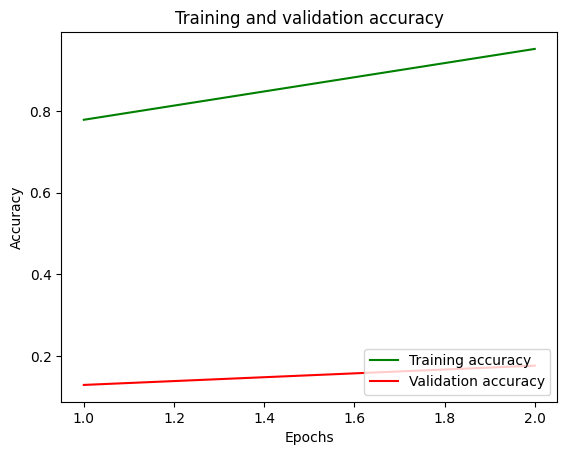

In [31]:
epochs = np.arange(1, len(acc) + 1)
plt.plot(epochs, acc, 'g', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

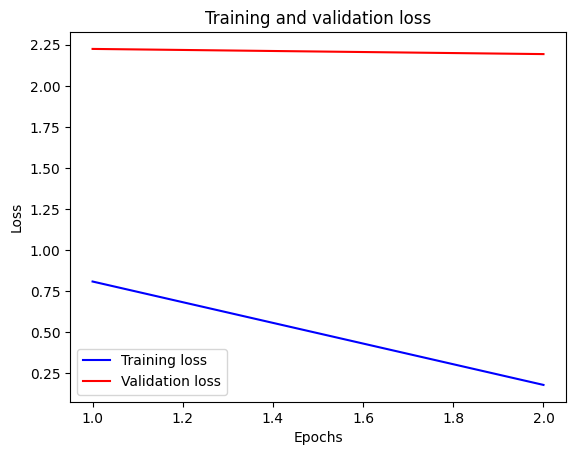

In [32]:
epochs = range(1, len(acc) + 1)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Generating the predictions on Validation Set**

In [33]:
y_predicted = model.predict(x_valid)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print('Predicted Label :',y_predicted_labels[:10])
print('Actual Label    :',y_validation[:10])

   1/1313 ━━━━━━━━━━━━━━━━━━━━ 5:13 239ms/step

   4/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step  

   7/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step

  10/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step

  13/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step

  16/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step

  19/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step

  22/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step

  25/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step

  28/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step

  31/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step

  34/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step

  37/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step

  40/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step

  43/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step

  45/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step

  47/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step

  49/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step

  51/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step

  53/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step

  55/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step

  57/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step

  59/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step

  61/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step

  63/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step

  65/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step

  67/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step

  69/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  71/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  73/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  75/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  77/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  80/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  82/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  84/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  86/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  88/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  90/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  92/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  94/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  96/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

  98/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 101/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 103/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 105/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 108/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 110/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 112/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 114/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step

 117/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step

 118/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step

 119/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step

 120/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step

 121/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step

 122/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step

 123/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step

 124/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step

 125/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step

 126/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step

 127/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step

 128/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step

 129/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step

 130/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step

 131/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step

 132/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step

 133/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step

 134/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step

 135/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step

 136/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step

 137/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step

 138/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step

 139/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step

 140/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step

 141/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step

 142/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step

 143/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step

 144/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step

 145/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step

 146/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step

 147/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 148/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 149/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 150/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 151/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 152/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step

 153/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step

 154/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 155/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 156/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 157/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 158/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 159/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 160/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step

 161/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step

 162/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 163/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 164/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 165/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 166/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 167/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 168/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step

 169/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step

 170/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 171/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 172/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 173/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 174/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 175/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 176/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 177/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 178/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step

 179/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step

 180/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step

 181/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step

 182/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step

 183/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step

 184/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 185/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 186/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 187/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 188/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 189/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step

 190/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 191/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 192/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 193/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 194/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 195/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 196/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 197/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 198/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 199/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 200/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 201/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 202/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step

 203/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 204/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 205/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 206/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 207/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 208/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 209/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 210/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 211/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 212/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 213/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 214/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 215/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 216/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step

 217/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 218/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 219/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 220/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 221/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 222/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 223/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 224/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 225/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 226/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 227/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 228/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 229/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 230/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 231/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 232/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 233/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 234/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step

 235/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 236/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 237/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 238/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 239/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 240/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 241/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 242/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 243/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 244/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 245/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 246/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 247/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step

 248/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step

 249/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step

 250/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step

 251/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step

 252/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step

 253/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 254/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 255/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 256/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 257/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 258/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 259/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 260/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 261/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 262/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 263/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 264/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 265/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 266/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 267/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 268/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 269/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 270/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 271/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 272/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step

 273/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 274/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 275/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 276/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 277/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 278/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 279/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 280/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step

 281/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 282/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 283/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 284/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 285/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 286/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 287/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 288/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 289/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 290/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 291/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 292/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 293/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 294/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 295/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 296/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 297/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 298/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 299/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 300/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 301/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 302/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 303/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 304/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 305/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 306/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 307/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 308/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 309/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 310/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 311/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step

 312/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 313/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 314/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 315/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 316/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 317/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 318/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 319/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 320/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 321/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 322/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 323/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 324/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 325/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 326/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 327/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 328/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 329/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 330/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 331/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 332/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 333/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 334/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 335/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 336/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 337/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 338/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 339/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 340/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 341/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 342/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step

 343/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 344/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 345/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 346/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 347/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 348/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step

 349/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 350/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 351/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 352/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 353/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 354/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 355/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 356/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 357/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 358/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 359/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 360/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 361/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 362/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 363/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 364/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 365/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 366/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 367/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 368/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 369/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 370/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 371/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 372/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 373/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 374/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 375/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 376/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 377/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 378/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 379/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step

 380/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 381/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 382/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 383/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 384/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 385/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 386/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 387/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 388/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 389/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 390/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 391/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 392/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 393/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 394/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 395/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step

 396/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 397/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 398/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 399/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 400/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 401/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 402/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 403/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 404/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 405/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 406/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 407/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 408/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 409/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 410/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 411/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 412/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 413/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step

 414/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 415/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 416/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 417/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 418/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 419/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 420/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 421/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 422/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 423/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 424/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 425/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 426/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 427/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 428/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 429/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 430/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 431/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 432/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 433/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 434/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 435/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 436/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 437/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 438/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 439/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 440/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 441/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 442/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 443/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step

 444/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 445/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 446/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 447/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 448/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 449/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 450/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 451/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 452/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 453/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 454/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 455/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 456/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step

 457/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 458/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 459/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 460/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 461/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 462/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 463/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 464/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 465/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 466/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 467/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 468/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 469/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 470/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 471/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step

 472/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 473/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 474/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 475/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 476/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 477/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 478/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 479/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 480/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 481/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 482/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 483/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 484/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 485/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 486/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 487/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 488/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 489/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 490/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 491/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 492/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 493/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 494/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 495/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 496/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step

 497/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 498/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 499/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 500/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 501/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 502/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 503/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 504/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 505/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 506/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 507/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 508/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 509/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 510/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 511/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 512/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 513/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 514/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 515/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 516/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 517/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 518/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 519/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 520/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 521/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step

 522/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 523/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 524/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 525/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 526/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 527/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 528/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 529/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 530/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 531/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 532/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 533/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 534/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 535/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 536/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 537/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 538/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 539/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 540/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 541/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 542/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step

 543/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step

 544/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step

 545/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step

 546/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 547/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 548/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 549/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 550/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 551/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 552/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 553/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 554/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 555/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 556/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 557/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 558/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 559/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 560/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 561/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 562/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 563/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 564/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 565/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 566/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 567/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 568/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 569/1313 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step

 570/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 571/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 572/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 573/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 574/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 575/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 576/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 577/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 578/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 579/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 580/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 581/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 582/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 583/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 584/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 585/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 586/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 587/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 588/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 589/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 590/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 591/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 592/1313 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step

 593/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 594/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 595/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 596/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 597/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 598/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 599/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 600/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 601/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 602/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 603/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 604/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 605/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 606/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 607/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 608/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 609/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 610/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 611/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 612/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 613/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 614/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 615/1313 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step

 616/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 617/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 618/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 619/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 620/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 621/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 622/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 623/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 624/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 625/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 626/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 627/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 628/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 629/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 630/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 631/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 632/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 633/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 634/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 635/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 636/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 637/1313 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step

 638/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 639/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 640/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 641/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 642/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 643/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 644/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 645/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 646/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 647/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 648/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 649/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 650/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 651/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 652/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 653/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 654/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 655/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 656/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 657/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 658/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 659/1313 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step

 660/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step

 661/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step

 662/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 663/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 664/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 665/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 666/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 667/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 668/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 669/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 670/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 671/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 672/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 673/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 674/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 675/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 676/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 677/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 678/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 679/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 680/1313 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step

 681/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 682/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 683/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 684/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 685/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 686/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 687/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 688/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 689/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 690/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 691/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 692/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 693/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 694/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 695/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 696/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 697/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 698/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 699/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 700/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 701/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 702/1313 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step

 703/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 704/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 705/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 706/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 707/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 708/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 709/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 710/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 711/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 712/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 713/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 714/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 715/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 716/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 717/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 718/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 719/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 720/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 721/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 722/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 723/1313 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step

 724/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 725/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 726/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 727/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 728/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 729/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 730/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 731/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 732/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 733/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 734/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 735/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 736/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 737/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 738/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 739/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 740/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 741/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 742/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 743/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 744/1313 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step

 745/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 746/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 747/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 748/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 749/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 750/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 751/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 752/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 753/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 754/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 755/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 756/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 757/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 758/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 759/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 760/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 761/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 762/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 763/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 764/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step

 765/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 766/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 767/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 768/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 769/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 770/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 771/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 772/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 773/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 774/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 775/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 776/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 777/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 778/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 779/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 780/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 781/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 782/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 783/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 784/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 785/1313 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step

 786/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 787/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 788/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 789/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 790/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 791/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 792/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 793/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 794/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 795/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 796/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 797/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 798/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 799/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 800/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 801/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 802/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 803/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 804/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 805/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step

 806/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 807/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 808/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 809/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 810/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 811/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 812/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 813/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 814/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 815/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 816/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 817/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 818/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 819/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 820/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 821/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 822/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 823/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 824/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 825/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 826/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step

 827/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 828/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 829/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 830/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 831/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 832/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 833/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 834/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 835/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 836/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 837/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 838/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 839/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 840/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 841/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 842/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 843/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 844/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 845/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 846/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step

 847/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 848/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 849/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 850/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 851/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 852/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 853/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 854/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 855/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 856/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 857/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 858/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 859/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 860/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 861/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 862/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 863/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 864/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 865/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step

 866/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step

 867/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 868/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 869/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 870/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 871/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 872/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 873/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 874/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 875/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 876/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 877/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 878/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 879/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 880/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 881/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 882/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 883/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 884/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 885/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 886/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step

 887/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 888/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 889/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 890/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 891/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 892/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 893/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 894/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 895/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 896/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 897/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 898/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 899/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 900/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 901/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 902/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 903/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 904/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 905/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 906/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step

 907/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 908/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 909/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 910/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 911/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 912/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 913/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 914/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 915/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 916/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 917/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 918/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 919/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 920/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 921/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 922/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 923/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 924/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 925/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 926/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step

 927/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 928/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 929/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 930/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 931/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 932/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 933/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 934/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 935/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 936/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 937/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 938/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 939/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 940/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 941/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 942/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 943/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 944/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 945/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step

 946/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 947/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 948/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 949/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 950/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 951/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 952/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 953/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 954/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 955/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 956/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 957/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 958/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 959/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 960/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 961/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 962/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 963/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 964/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 965/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step

 966/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 967/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 968/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 969/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 970/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 971/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 972/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 973/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 974/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 975/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 976/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 977/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 978/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 979/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 980/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 981/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 982/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 983/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 984/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 985/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step

 986/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 987/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 988/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 989/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 990/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 991/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 992/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 993/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 994/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 995/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 996/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 997/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 998/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

 999/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1000/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1001/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1002/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1003/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1004/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step

1005/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1006/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1007/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1008/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1009/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1010/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1011/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1012/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1013/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1014/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1015/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1016/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1017/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1018/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1019/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1020/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1021/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1022/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1023/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1024/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step

1025/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1026/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1027/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1028/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1029/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1030/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1031/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1032/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1033/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1034/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1035/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1036/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1037/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1038/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1039/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1040/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1041/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1042/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1043/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step

1044/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1045/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1046/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1047/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1048/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1049/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1050/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1051/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1052/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1053/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1054/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1055/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1056/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1057/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1058/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1059/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1060/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1061/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1062/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1063/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step

1064/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1065/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1066/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1067/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1068/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1069/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1070/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1071/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1072/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1073/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1074/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1075/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1076/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1077/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1078/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1079/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1080/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1081/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1082/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step

1083/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1084/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1085/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1086/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1087/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1088/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1089/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1090/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1091/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1092/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1093/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1094/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1095/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1096/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1097/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1098/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1099/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1100/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1101/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1102/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step

1103/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1104/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1105/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1106/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1107/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1108/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1109/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1110/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1111/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1112/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1113/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1114/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1115/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1116/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1117/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1118/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1119/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1120/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1121/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step

1122/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step 

1123/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1124/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1125/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1126/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1127/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1128/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1129/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1130/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1131/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1132/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1133/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1134/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1135/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1136/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1137/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1138/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1139/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1140/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step

1141/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1142/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1143/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1144/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1145/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1146/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1147/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1148/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1149/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1150/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1151/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1152/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1153/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1154/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1155/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1156/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1157/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1158/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1159/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step

1160/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1161/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1162/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1163/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1164/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1165/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1166/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1167/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1168/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1169/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1170/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1171/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1172/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1173/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1174/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1175/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1176/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1177/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1178/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1179/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

1180/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1181/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1182/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1183/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1184/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1185/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1186/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1187/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1188/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1189/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1190/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1191/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1192/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1193/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1194/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1195/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1196/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1197/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1198/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step

1199/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1200/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1201/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1202/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1203/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1204/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1205/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1206/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1207/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1208/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1209/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1210/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1211/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1212/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1213/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1214/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1215/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1216/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1217/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

1218/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1219/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1220/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1221/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1222/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1223/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1224/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1225/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1226/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1227/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1228/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1229/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1230/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1231/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1232/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1233/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1234/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1235/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1236/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step

1237/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1238/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1239/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1240/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1241/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1242/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1243/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1244/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1245/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1246/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1247/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1248/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1249/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1250/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1251/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1252/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1253/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1254/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1255/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step

1256/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step

1257/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step

1258/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step

1259/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1260/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1261/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1262/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1263/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1264/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1265/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1266/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1267/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1268/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1269/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1270/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1271/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1272/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1273/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1274/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

1275/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1276/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1277/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1278/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1279/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1280/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1281/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1282/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1283/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1284/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1285/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1286/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1287/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1288/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1289/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1290/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1291/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1292/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1293/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

1294/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1295/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1296/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1297/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1298/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1300/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1301/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1302/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1303/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1304/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1305/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1306/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1307/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1308/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1309/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1310/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 70s 53ms/step


Predicted Label : [1, 1, 2, 1, 1, 2, 1, 1, 1, 1]
Actual Label    : [5 0 4 1 9 2 1 3 1 4]


**Confusion Matrix**

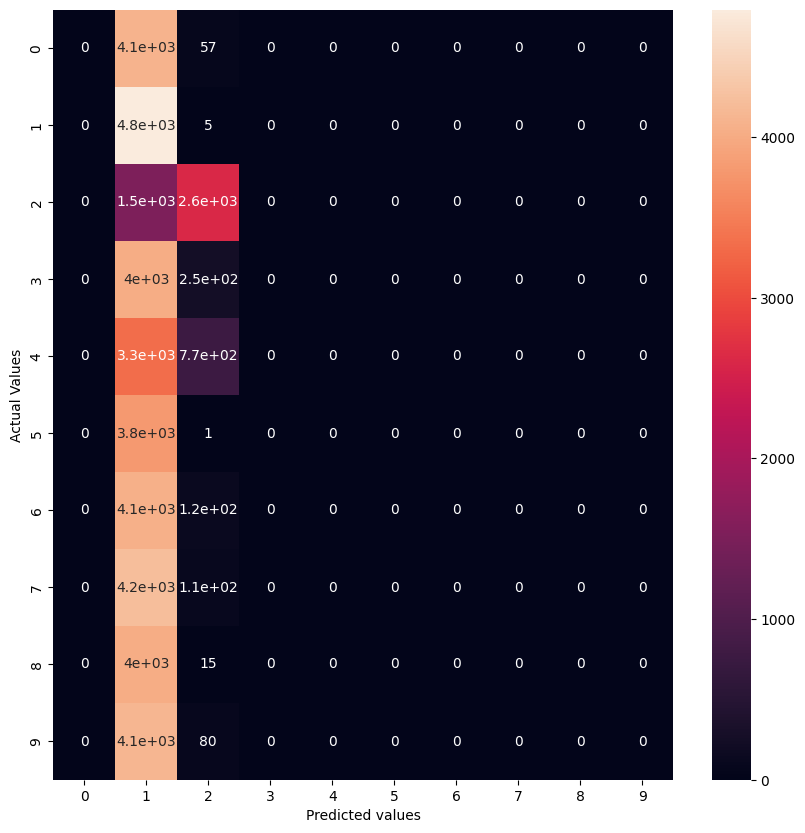

In [34]:
cm = tf.math.confusion_matrix(labels = y_validation, predictions=y_predicted_labels)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.show()

In [35]:
print("Classification Report: \n", classification_report(y_validation, y_predicted_labels))


Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      4143
           1       0.13      1.00      0.22      4799
           2       0.65      0.63      0.64      4147
           3       0.00      0.00      0.00      4268
           4       0.00      0.00      0.00      4099
           5       0.00      0.00      0.00      3784
           6       0.00      0.00      0.00      4180
           7       0.00      0.00      0.00      4330
           8       0.00      0.00      0.00      4040
           9       0.00      0.00      0.00      4210

    accuracy                           0.18     42000
   macro avg       0.08      0.16      0.09     42000
weighted avg       0.08      0.18      0.09     42000



C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

**Validating the predictions**

In [36]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("Pred: {} ({:2.0f}%) \n Truth : {}".format(predicted_label, (100*np.max(predictions_array)),
                                                          true_label), color=color)

In [37]:
def plot_value_array(i, predictions_array, true_labels):
    true_label = true_labels[i]
    plt.grid(False)
    plt.xticks(range(10))

    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)


    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

In [38]:
# for 25 images
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 523)
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_predicted[i], y_validation, x_valid)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_predicted[i], y_validation)
plt.tight_layout()
plt.show()

**Inaccurate Predictions**

In [39]:
count = 0
wrong_predictions = []
for i in range(len(y_validation)):
    predicted_label = np.argmax(y_predicted[i])
    if predicted_label != y_validation[i]:
        count +=1
        wrong_predictions.append(i)
print('There are',count,'wrong predictions in Validation datasets')
print('Wrong predicted indices :\n',wrong_predictions)

There are 34587 wrong predictions in Validation datasets
Wrong predicted indices :
 [0, 1, 2, 4, 7, 9, 10, 11, 12, 13, 15, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 68, 69, 71, 73, 74, 75, 76, 79, 80, 81, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 103, 106, 107, 108, 109, 110, 111, 114, 115, 116, 117, 118, 119, 121, 123, 125, 126, 127, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 155, 156, 157, 158, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 172, 173, 175, 176, 179, 180, 181, 182, 183, 185, 186, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 202, 203, 204, 206, 207, 209, 210, 212, 214, 215, 216, 217, 218, 219, 221, 222, 223, 225, 226, 227, 228, 229, 230, 232, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247

In [40]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 723)

for ix in range(num_images):
    i = wrong_predictions[ix]
    plt.subplot(num_rows, 2*num_cols, 2*ix+1)
    plot_image(i, y_predicted[i], y_validation, x_valid)
    plt.subplot(num_rows, 2*num_cols, 2*ix+2)
    plot_value_array(i, y_predicted[i], y_validation)
plt.tight_layout()
plt.show()

**Generating Predictions for Test data set**

In [41]:
y_predicted = model.predict(X_test.reshape(-1, 28, 28, 1) / 255.0)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print('Predicted Label :',y_predicted_labels[:10])
print('Actual Label    :',Y_test[:10])

  1/313 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step

  2/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step

  3/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step

  4/313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step

  5/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step

  6/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step

  7/313 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step

  8/313 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step

  9/313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step

 10/313 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step

 11/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step

 12/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 13/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 14/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 15/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 16/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 17/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 18/313 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step

 19/313 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step

 20/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 21/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 22/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 23/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 24/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 25/313 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step

 26/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 27/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 28/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 29/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 30/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 31/313 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step

 32/313 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step

 33/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 34/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 35/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 36/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 37/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 38/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 39/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 40/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 41/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 42/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 43/313 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step

 44/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 45/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 46/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 47/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 48/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 49/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 50/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 51/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 52/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 53/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 54/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 55/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 56/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 57/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 58/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 59/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 60/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 61/313 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step

 62/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 63/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 64/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 65/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 66/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 67/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 68/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 69/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 70/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 71/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 72/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 73/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 74/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 75/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 76/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 77/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 78/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 79/313 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step

 80/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 81/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 82/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 83/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 84/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 85/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 86/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 87/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 88/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 89/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 90/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 91/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 92/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 93/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 94/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 95/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 96/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 97/313 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

 98/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

 99/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

100/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

101/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

102/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

103/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

104/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

105/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

106/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

107/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

108/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

109/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

110/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

111/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

112/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

113/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

114/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

115/313 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

116/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

117/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

118/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

119/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

120/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

121/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

122/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

123/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

124/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

125/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

126/313 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step

127/313 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step

128/313 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step

129/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

130/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

131/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

132/313 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

133/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step 

134/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

135/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

136/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

137/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

138/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

139/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

140/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

141/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

142/313 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

143/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

144/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

145/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

146/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

147/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

148/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

149/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

150/313 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step

151/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

152/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

153/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

154/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

155/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

156/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

157/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

158/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

159/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

160/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

161/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

162/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

163/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

164/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

165/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

166/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

167/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

168/313 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step

169/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

170/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

171/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

172/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

173/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

174/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

175/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

176/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

177/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

178/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

179/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

180/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

181/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

182/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

183/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

184/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

185/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

186/313 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

187/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

188/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

189/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

190/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

191/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

192/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

193/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

194/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

195/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

196/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

197/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

198/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

199/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

200/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

201/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

202/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

203/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

204/313 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step

205/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

206/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

207/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

208/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

209/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

210/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

211/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

212/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

213/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

214/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

215/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

216/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

217/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

218/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

219/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

220/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

221/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

222/313 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step

223/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

224/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

225/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

226/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

227/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

228/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

229/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

230/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

231/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

232/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

233/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

234/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

235/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

236/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

237/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

238/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

239/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

240/313 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step

241/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

242/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

243/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

244/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

245/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

246/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

247/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

248/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

249/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

250/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

251/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

252/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

253/313 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step

254/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

255/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

256/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

257/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

258/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

259/313 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

260/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

261/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

262/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

263/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

264/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

265/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

266/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

267/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

268/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

269/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

270/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

271/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

272/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

273/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

274/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

275/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

276/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

277/313 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

278/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

279/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

280/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

281/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

282/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

283/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

284/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

285/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

286/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

287/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

288/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

289/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

290/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

291/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

292/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

293/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

294/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

295/313 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

296/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

297/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

299/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

300/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

301/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

302/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

303/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

305/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step


Predicted Label : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Actual Label    : [7 2 1 0 4 1 4 9 5 9]


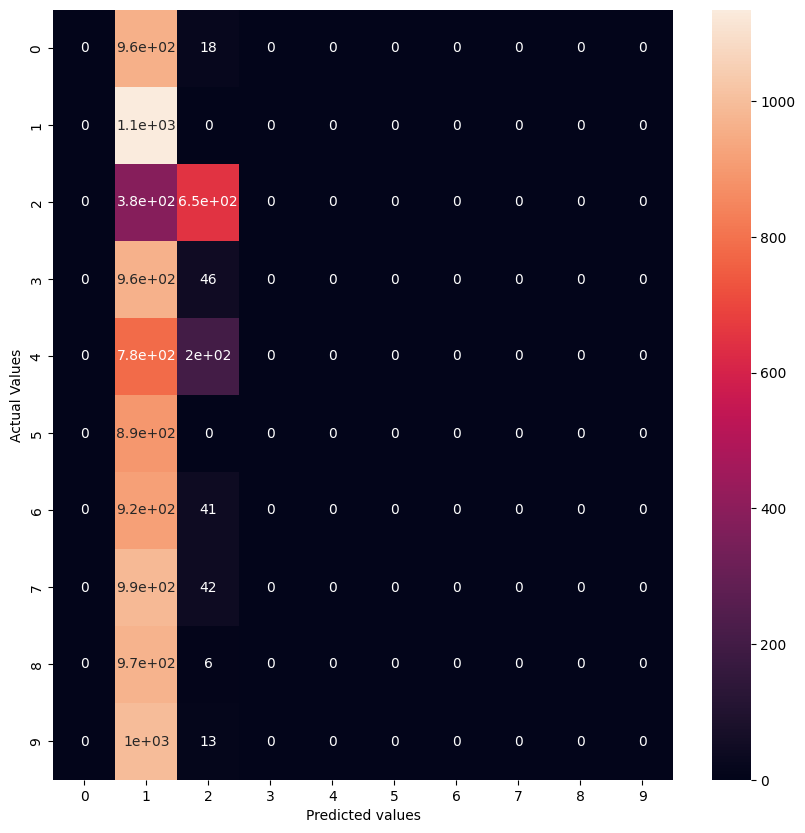

In [42]:
cm = tf.math.confusion_matrix(labels = Y_test, predictions=y_predicted_labels)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.show()

In [43]:
print("Classification Report: \n", classification_report(Y_test, y_predicted_labels)) ## 95%accuracy


Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.13      1.00      0.22      1135
           2       0.64      0.63      0.63      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.18     10000
   macro avg       0.08      0.16      0.09     10000
weighted avg       0.08      0.18      0.09     10000



C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [44]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 523)
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, y_predicted[i], Y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, y_predicted[i], Y_test)
plt.tight_layout()
plt.show()

**Inaccurate Predictions**

In [45]:
count = 0
wrong_predictions = []
for i in range(len(Y_test)):
    predicted_label = np.argmax(y_predicted[i])
    if predicted_label != Y_test[i]:
        count +=1
        wrong_predictions.append(i)
print('There are',count,'wrong predictions in test datasets')
print('Wrong predicted indices :\n',wrong_predictions)

There are 8216 wrong predictions in test datasets
Wrong predicted indices :
 [0, 1, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 32, 33, 34, 36, 38, 41, 42, 43, 44, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 75, 76, 77, 78, 79, 80, 81, 83, 84, 85, 86, 87, 88, 90, 91, 92, 93, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 138, 139, 140, 141, 142, 144, 146, 148, 149, 150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 169, 170, 171, 172, 173, 174, 175, 177, 179, 181, 182, 183, 184, 185, 186, 187, 188, 192, 193, 194, 195, 197, 198, 200, 201, 205, 206, 207, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 223, 226, 227, 229, 230, 231, 232, 233, 234, 235, 238, 240, 241, 242, 243, 244, 245, 246, 247, 248, 24

In [46]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows), dpi = 723)

for ix in range(num_images):
    i = wrong_predictions[ix]
    plt.subplot(num_rows, 2*num_cols, 2*ix+1)
    plot_image(i, y_predicted[i], Y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*ix+2)
    plot_value_array(i, y_predicted[i], Y_test)
plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split

seed = 4
tf.random.set_seed(seed)

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed)

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=2, validation_data=(x_val, y_val))

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")
print(test_accuracy*100)

C:\Users\rajam\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2


   1/1500 ━━━━━━━━━━━━━━━━━━━━ 53:53 2s/step - accuracy: 0.0938 - loss: 2.5350

   9/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1734 - loss: 2.3791  

  18/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2609 - loss: 2.2417

  27/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3175 - loss: 2.1362

  35/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3591 - loss: 2.0479

  44/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3991 - loss: 1.9537

  53/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4331 - loss: 1.8673

  62/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4621 - loss: 1.7882

  70/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4847 - loss: 1.7239

  79/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5067 - loss: 1.6586

  89/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5284 - loss: 1.5931

  98/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5457 - loss: 1.5395

 108/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5630 - loss: 1.4857

 117/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5769 - loss: 1.4419

 127/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5909 - loss: 1.3974

 136/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6023 - loss: 1.3606

 145/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6128 - loss: 1.3264

 154/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6227 - loss: 1.2944

 163/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6318 - loss: 1.2648

 172/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6402 - loss: 1.2370

 182/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6490 - loss: 1.2081

 191/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6564 - loss: 1.1838

 201/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6640 - loss: 1.1584

 210/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6704 - loss: 1.1371

 220/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6770 - loss: 1.1149

 230/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6832 - loss: 1.0941

 240/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6891 - loss: 1.0744

 249/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6940 - loss: 1.0576

 259/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6993 - loss: 1.0398

 269/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7043 - loss: 1.0229

 279/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7090 - loss: 1.0070

 288/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7131 - loss: 0.9932

 298/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7174 - loss: 0.9786

 307/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7211 - loss: 0.9660

 317/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7251 - loss: 0.9526

 326/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7286 - loss: 0.9410

 336/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7322 - loss: 0.9286

 346/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7357 - loss: 0.9167

 355/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7387 - loss: 0.9064

 364/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7416 - loss: 0.8964

 374/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7447 - loss: 0.8858

 384/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7477 - loss: 0.8755

 393/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7503 - loss: 0.8666

 402/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7528 - loss: 0.8579

 411/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7553 - loss: 0.8496

 421/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7579 - loss: 0.8406

 431/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7604 - loss: 0.8318

 441/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7629 - loss: 0.8234

 451/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7653 - loss: 0.8152

 461/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7676 - loss: 0.8073

 469/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7693 - loss: 0.8012

 478/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7713 - loss: 0.7944

 488/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7734 - loss: 0.7871

 498/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7754 - loss: 0.7800

 507/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7772 - loss: 0.7738

 516/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7790 - loss: 0.7678

 525/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7807 - loss: 0.7619

 535/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7825 - loss: 0.7555

 544/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7841 - loss: 0.7499

 554/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7859 - loss: 0.7438

 563/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7874 - loss: 0.7385

 573/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7891 - loss: 0.7327

 583/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7907 - loss: 0.7270

 593/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7923 - loss: 0.7215

 603/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7938 - loss: 0.7161

 613/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7953 - loss: 0.7109

 622/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7966 - loss: 0.7063

 632/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7981 - loss: 0.7013

 642/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7995 - loss: 0.6964

 651/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8007 - loss: 0.6921

 660/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8019 - loss: 0.6879

 669/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8031 - loss: 0.6837

 679/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8044 - loss: 0.6792

 688/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8055 - loss: 0.6752

 697/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8067 - loss: 0.6713

 706/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8078 - loss: 0.6674

 716/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8089 - loss: 0.6632

 726/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8101 - loss: 0.6591

 736/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8113 - loss: 0.6551

 746/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8124 - loss: 0.6512

 756/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8135 - loss: 0.6473

 765/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8145 - loss: 0.6439

 775/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8155 - loss: 0.6402

 785/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8166 - loss: 0.6366

 795/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8176 - loss: 0.6330

 805/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8186 - loss: 0.6295

 814/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8195 - loss: 0.6264

 823/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8203 - loss: 0.6233

 832/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8212 - loss: 0.6203

 841/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8220 - loss: 0.6173

 850/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8229 - loss: 0.6144

 860/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8238 - loss: 0.6112

 868/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8245 - loss: 0.6087

 876/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8252 - loss: 0.6063

 885/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8260 - loss: 0.6035

 894/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8267 - loss: 0.6008

 904/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8276 - loss: 0.5978

 913/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8283 - loss: 0.5952

 922/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8291 - loss: 0.5926

 931/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8298 - loss: 0.5901

 940/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8305 - loss: 0.5876

 950/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8313 - loss: 0.5848

 959/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8320 - loss: 0.5823

 969/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8328 - loss: 0.5797

 979/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8335 - loss: 0.5770

 989/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8343 - loss: 0.5744

 998/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8349 - loss: 0.5721

1008/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8356 - loss: 0.5696

1018/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8364 - loss: 0.5671

1028/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8371 - loss: 0.5646

1038/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8378 - loss: 0.5622

1047/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8384 - loss: 0.5601

1056/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8390 - loss: 0.5579

1065/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8396 - loss: 0.5559

1074/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8402 - loss: 0.5538

1083/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8408 - loss: 0.5517

1092/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8413 - loss: 0.5497

1101/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8419 - loss: 0.5477

1109/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8424 - loss: 0.5460

1118/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8430 - loss: 0.5440

1127/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8435 - loss: 0.5421

1136/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8441 - loss: 0.5402

1145/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8446 - loss: 0.5383

1155/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8452 - loss: 0.5362

1164/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8457 - loss: 0.5344

1173/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8462 - loss: 0.5326

1182/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8467 - loss: 0.5308

1191/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8472 - loss: 0.5290

1200/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8477 - loss: 0.5273

1209/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8482 - loss: 0.5255

1218/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8487 - loss: 0.5238

1227/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8492 - loss: 0.5221

1234/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8496 - loss: 0.5208

1239/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8499 - loss: 0.5199

1246/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8502 - loss: 0.5186

1253/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8506 - loss: 0.5173

1261/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8510 - loss: 0.5158

1269/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8514 - loss: 0.5144

1278/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8519 - loss: 0.5128

1287/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8523 - loss: 0.5112

1296/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8527 - loss: 0.5096

1305/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8532 - loss: 0.5081

1313/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8536 - loss: 0.5067

1322/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8540 - loss: 0.5052

1331/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8544 - loss: 0.5037

1340/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8549 - loss: 0.5022

1349/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8553 - loss: 0.5007

1358/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8557 - loss: 0.4992

1367/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8561 - loss: 0.4977

1376/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8565 - loss: 0.4963

1385/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8569 - loss: 0.4949

1394/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8573 - loss: 0.4934

1403/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8577 - loss: 0.4920

1412/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8581 - loss: 0.4906

1421/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8585 - loss: 0.4893

1430/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8589 - loss: 0.4879

1439/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8593 - loss: 0.4865

1449/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8597 - loss: 0.4851

1458/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8601 - loss: 0.4837

1467/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8605 - loss: 0.4824

1477/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8609 - loss: 0.4809

1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8612 - loss: 0.4796

1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8616 - loss: 0.4782

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9218 - loss: 0.2653 - val_accuracy: 0.9562 - val_loss: 0.1416


Epoch 2/2


   1/1500 ━━━━━━━━━━━━━━━━━━━━ 1:19 53ms/step - accuracy: 0.9375 - loss: 0.3620

  13/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9525 - loss: 0.1780   

  22/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9514 - loss: 0.1655

  32/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9513 - loss: 0.1581

  42/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9510 - loss: 0.1558

  51/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9510 - loss: 0.1561

  61/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9514 - loss: 0.1557

  71/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9517 - loss: 0.1551

  81/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9520 - loss: 0.1541

  90/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9524 - loss: 0.1529

  99/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9526 - loss: 0.1519

 109/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9528 - loss: 0.1510

 118/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9530 - loss: 0.1502

 128/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9531 - loss: 0.1494

 138/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9532 - loss: 0.1485

 147/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9534 - loss: 0.1477

 157/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9536 - loss: 0.1467

 167/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9538 - loss: 0.1460

 176/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9540 - loss: 0.1453

 186/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9542 - loss: 0.1446

 195/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9544 - loss: 0.1440

 205/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9546 - loss: 0.1434

 213/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9547 - loss: 0.1430

 221/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9548 - loss: 0.1428

 231/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9549 - loss: 0.1425

 241/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9550 - loss: 0.1422

 251/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9552 - loss: 0.1420

 260/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9553 - loss: 0.1417

 269/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9554 - loss: 0.1415

 278/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9555 - loss: 0.1413

 288/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9556 - loss: 0.1411

 296/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9557 - loss: 0.1410

 305/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9558 - loss: 0.1408

 315/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9559 - loss: 0.1405

 325/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9560 - loss: 0.1403

 334/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9562 - loss: 0.1400

 343/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9563 - loss: 0.1398

 353/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9564 - loss: 0.1396

 363/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9565 - loss: 0.1393

 373/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9566 - loss: 0.1391

 383/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9567 - loss: 0.1389

 393/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9568 - loss: 0.1386

 403/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9569 - loss: 0.1384

 413/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9570 - loss: 0.1382

 423/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9571 - loss: 0.1379

 432/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9572 - loss: 0.1377

 442/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9573 - loss: 0.1374

 451/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9574 - loss: 0.1372

 460/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9575 - loss: 0.1370

 470/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9576 - loss: 0.1368

 479/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9577 - loss: 0.1366

 489/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9578 - loss: 0.1363

 498/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9579 - loss: 0.1361

 508/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9580 - loss: 0.1359

 517/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9580 - loss: 0.1357

 527/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9581 - loss: 0.1355

 536/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9582 - loss: 0.1353

 546/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9583 - loss: 0.1351

 555/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9584 - loss: 0.1349

 565/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9585 - loss: 0.1347

 575/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9586 - loss: 0.1345

 585/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9586 - loss: 0.1342

 594/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9587 - loss: 0.1341

 604/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9588 - loss: 0.1339

 613/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9589 - loss: 0.1337

 621/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9589 - loss: 0.1335

 630/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9590 - loss: 0.1334

 640/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9591 - loss: 0.1332

 649/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9591 - loss: 0.1330

 659/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9592 - loss: 0.1329

 669/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9593 - loss: 0.1327

 679/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9593 - loss: 0.1325

 688/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9594 - loss: 0.1323

 697/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9595 - loss: 0.1322

 707/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9595 - loss: 0.1320

 717/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9596 - loss: 0.1318

 727/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9597 - loss: 0.1316

 737/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9597 - loss: 0.1315

 747/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9598 - loss: 0.1313

 757/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9598 - loss: 0.1311

 767/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9599 - loss: 0.1310

 776/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9599 - loss: 0.1308

 785/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9600 - loss: 0.1307

 795/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9600 - loss: 0.1306

 804/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9601 - loss: 0.1305

 814/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9601 - loss: 0.1303

 824/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9602 - loss: 0.1302

 834/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9602 - loss: 0.1300

 844/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9603 - loss: 0.1299

 853/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9603 - loss: 0.1298

 863/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9604 - loss: 0.1296

 873/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9604 - loss: 0.1295

 882/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9605 - loss: 0.1294

 892/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9605 - loss: 0.1292

 901/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9606 - loss: 0.1291

 911/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9606 - loss: 0.1290

 921/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9607 - loss: 0.1288

 929/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9607 - loss: 0.1287

 939/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9607 - loss: 0.1286

 949/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9608 - loss: 0.1285

 959/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9608 - loss: 0.1283

 969/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9609 - loss: 0.1282

 979/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9609 - loss: 0.1281

 988/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9609 - loss: 0.1280

 997/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9610 - loss: 0.1279

1007/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9610 - loss: 0.1278

1016/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9611 - loss: 0.1277

1024/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9611 - loss: 0.1276

1034/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9611 - loss: 0.1275

1044/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9612 - loss: 0.1274

1054/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9612 - loss: 0.1272

1063/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9612 - loss: 0.1271

1073/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9613 - loss: 0.1270

1083/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9613 - loss: 0.1269

1093/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9613 - loss: 0.1268

1103/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9614 - loss: 0.1267

1113/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9614 - loss: 0.1266

1124/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9615 - loss: 0.1265

1135/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9615 - loss: 0.1264

1145/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9615 - loss: 0.1263

1155/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9616 - loss: 0.1261

1165/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9616 - loss: 0.1260

1174/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9616 - loss: 0.1259

1183/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9617 - loss: 0.1259

1194/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9617 - loss: 0.1257

1204/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9617 - loss: 0.1256

1214/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9617 - loss: 0.1255

1224/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9618 - loss: 0.1255

1235/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9618 - loss: 0.1253

1245/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9618 - loss: 0.1252

1256/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9619 - loss: 0.1251

1264/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9619 - loss: 0.1251

1272/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9619 - loss: 0.1250

1279/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9620 - loss: 0.1249

1287/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9620 - loss: 0.1248

1296/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9620 - loss: 0.1248

1306/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9620 - loss: 0.1247

1315/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9621 - loss: 0.1246

1324/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9621 - loss: 0.1245

1334/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9621 - loss: 0.1244

1343/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9622 - loss: 0.1243

1351/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9622 - loss: 0.1242

1361/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9622 - loss: 0.1241

1370/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9622 - loss: 0.1241

1380/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9623 - loss: 0.1240

1389/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9623 - loss: 0.1239

1398/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9623 - loss: 0.1238

1408/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9624 - loss: 0.1237

1417/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9624 - loss: 0.1236

1424/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9624 - loss: 0.1236

1433/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9624 - loss: 0.1235

1442/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9625 - loss: 0.1234

1452/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9625 - loss: 0.1233

1462/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9625 - loss: 0.1232

1472/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9626 - loss: 0.1231

1479/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9626 - loss: 0.1231

1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9626 - loss: 0.1230

1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9626 - loss: 0.1229

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9670 - loss: 0.1092 - val_accuracy: 0.9666 - val_loss: 0.1023


Test Accuracy: 0.97
96.71000242233276
